In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ==============================
# PROJECT PATHS
# ==============================

DATASET_DIR = Path("/content/drive/MyDrive/SER_datasets")

RESULT_DIR = Path("/content/results")
FEATURE_DIR = Path("/content/features")
MODEL_DIR = Path("/content/models")

# Create folders
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Setup completed")

Mounted at /content/drive
✅ Setup completed


In [ ]:
!pip -q install librosa soundfile scikit-learn joblib

In [ ]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

SER_DIR = MYDRIVE / "SER_datasets"

print("SER_datasets exists:", SER_DIR.exists())
print("\nContents of SER_datasets:")

if SER_DIR.exists():
    for item in SER_DIR.iterdir():
        print(" -", item)
else:
    print("SER_datasets was not found.")

SER_datasets exists: True

Contents of SER_datasets:
 - /content/drive/MyDrive/SER_datasets/archive.zip
 - /content/drive/MyDrive/SER_datasets/t9h6p943xy-5.zip
 - /content/drive/MyDrive/SER_datasets/English_RAVDESS
 - /content/drive/MyDrive/SER_datasets/BanglaSer
 - /content/drive/MyDrive/SER_datasets/results
 - /content/drive/MyDrive/SER_datasets/models
 - /content/drive/MyDrive/SER_datasets/features


In [ ]:
print("\nSearching inside SER_datasets...\n")

for item in SER_DIR.rglob("*"):
    if item.is_file():
        print(item)


Searching inside SER_datasets...

/content/drive/MyDrive/SER_datasets/archive.zip
/content/drive/MyDrive/SER_datasets/t9h6p943xy-5.zip
/content/drive/MyDrive/SER_datasets/results/bangla_emotion_distribution.png
/content/drive/MyDrive/SER_datasets/results/bangla_baseline_comparison.png
/content/drive/MyDrive/SER_datasets/results/bangla_confusion_matrix.png
/content/drive/MyDrive/SER_datasets/results/bangla_final_results.csv
/content/drive/MyDrive/SER_datasets/models/bangla_label_encoder.pkl
/content/drive/MyDrive/SER_datasets/models/bangla_ser_model.pkl
/content/drive/MyDrive/SER_datasets/features/Bangla_features.csv
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-03-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-03-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-02-01.wav
/content/drive/MyDrive/SER_datasets/BanglaSer/t9h6p943xy-5/BanglaS

In [ ]:
import zipfile
from pathlib import Path

SER_DIR = Path("/content/drive/MyDrive/SER_datasets")

zip_files = list(SER_DIR.glob("*.zip"))

for zip_path in zip_files:
    print("\n" + "=" * 60)
    print("ZIP FILE:", zip_path.name)
    print("=" * 60)

    with zipfile.ZipFile(zip_path, "r") as z:
        files = z.namelist()

        print("Total items:", len(files))
        print("\nFirst 20 items:")

        for item in files[:20]:
            print(item)


ZIP FILE: archive.zip
Total items: 2880

First 20 items:
Actor_01/03-01-01-01-01-01-01.wav
Actor_01/03-01-01-01-01-02-01.wav
Actor_01/03-01-01-01-02-01-01.wav
Actor_01/03-01-01-01-02-02-01.wav
Actor_01/03-01-02-01-01-01-01.wav
Actor_01/03-01-02-01-01-02-01.wav
Actor_01/03-01-02-01-02-01-01.wav
Actor_01/03-01-02-01-02-02-01.wav
Actor_01/03-01-02-02-01-01-01.wav
Actor_01/03-01-02-02-01-02-01.wav
Actor_01/03-01-02-02-02-01-01.wav
Actor_01/03-01-02-02-02-02-01.wav
Actor_01/03-01-03-01-01-01-01.wav
Actor_01/03-01-03-01-01-02-01.wav
Actor_01/03-01-03-01-02-01-01.wav
Actor_01/03-01-03-01-02-02-01.wav
Actor_01/03-01-03-02-01-01-01.wav
Actor_01/03-01-03-02-01-02-01.wav
Actor_01/03-01-03-02-02-01-01.wav
Actor_01/03-01-03-02-02-02-01.wav

ZIP FILE: t9h6p943xy-5.zip
Total items: 1467

First 20 items:
t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-02-02-01.wav
t9h6p943xy-5/BanglaSER/Actor 01/03-01-02-01-01-01-01.wav
t9h6p943xy-5/BanglaSER/Actor 01/03-01-01-01-01-03-01.wav
t9h6p943xy-5/BanglaSER/Actor

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
import zipfile
from pathlib import Path

SER_DIR = Path("/content/drive/MyDrive/SER_datasets")
ZIP_PATH = SER_DIR / "archive.zip"

EXTRACT_DIR = SER_DIR / "English_RAVDESS"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("English dataset extracted successfully.")
print("Location:")
print(EXTRACT_DIR)

KeyboardInterrupt: 

In [ ]:
print("Searching for Actor folders...\n")

actor_folders = sorted([
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_dir() and p.name.lower().startswith("actor")
])

print("Actor folders found:", len(actor_folders))

for folder in actor_folders[:30]:
    print(folder)

Searching for Actor folders...

Actor folders found: 48
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_02
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_03
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_04
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_05
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_06
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_07
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_08
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_09
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_10
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_11
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_12
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_13
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_14
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_15
/content/drive/MyDrive/SER_da

In [ ]:
audio_files = sorted(
    EXTRACT_DIR.rglob("*.wav")
)

print("Total WAV files:", len(audio_files))

print("\nFirst 10 files:")

for file in audio_files[:10]:
    print(file)

Total WAV files: 2880

First 10 files:
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-01-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-01-01-01-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-01-01-02-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-01-01-02-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-01-01-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-01-02-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-01-02-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-02-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-02-02-01-02-01.wav


In [ ]:
ENGLISH_DIR = EXTRACT_DIR

print("English dataset path:")
print(ENGLISH_DIR)

print("\nNumber of WAV files:", len(list(ENGLISH_DIR.rglob("*.wav"))))

English dataset path:
/content/drive/MyDrive/SER_datasets/English_RAVDESS

Number of WAV files: 2880


In [ ]:
audio_extensions = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}

audio_files = [
    p for p in ENGLISH_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in audio_extensions
]

print("Total audio files found:", len(audio_files))

print("\nFirst 10 files:")
for file in audio_files[:10]:
    print(file)

Total audio files found: 2880

First 10 files:
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-01-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-02-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-02-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-01-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-01-01-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-01-02-02-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-01-02-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-02-01-01-01.wav
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-04-02-01-02-01.wav


In [ ]:
EMOTION_MAP = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}


def extract_emotion_from_filename(file_path):
    filename = Path(file_path).stem

    parts = filename.split("-")

    if len(parts) != 7:
        return None

    try:
        emotion_code = int(parts[2])
    except ValueError:
        return None

    return EMOTION_MAP.get(emotion_code)


def extract_speaker_from_path(file_path):
    """
    Extract speaker from folders such as:
    Actor 01
    Actor 02
    etc.
    """

    path = Path(file_path)

    for part in path.parts:
        match = re.fullmatch(r"Actor\s*(\d+)", part, re.IGNORECASE)

        if match:
            return f"Actor_{int(match.group(1)):02d}"

    # Backup: try filename's final field if necessary
    filename = path.stem
    parts = filename.split("-")

    if len(parts) == 7:
        try:
            speaker_code = int(parts[-1])
            return f"Actor_{speaker_code:02d}"
        except:
            pass

    return None

In [ ]:
test_files = [
    "03-01-01-01-01-01-01.wav",
    "03-01-03-01-01-01-01.wav",
    "03-01-05-01-01-01-01.wav",
    "03-01-08-01-01-01-01.wav"
]

for filename in test_files:
    print(
        filename,
        "→",
        extract_emotion_from_filename(filename)
    )

03-01-01-01-01-01-01.wav → neutral
03-01-03-01-01-01-01.wav → happy
03-01-05-01-01-01-01.wav → angry
03-01-08-01-01-01-01.wav → surprised


In [ ]:
records = []

for file_path in audio_files:

    emotion = extract_emotion_from_filename(file_path)
    speaker = extract_speaker_from_path(file_path)

    if emotion is not None and speaker is not None:
        records.append({
            "file_path": str(file_path),
            "speaker": speaker,
            "emotion": emotion,
            "language": "English"
        })

metadata = pd.DataFrame(records)

print("Valid audio files:", len(metadata))

print("\nDataset preview:")
display(metadata.head())

print("\nEmotion distribution:")
print(metadata["emotion"].value_counts())

print("\nSpeaker count:")
print(metadata["speaker"].nunique())

Valid audio files: 2880

Dataset preview:


,file_path,speaker,emotion,language
0,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,English
1,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,English
2,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,English
3,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,English
4,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,sad,English



Emotion distribution:
emotion
happy        384
sad          384
angry        384
fearful      384
disgust      384
surprised    384
calm         384
neutral      192
Name: count, dtype: int64

Speaker count:
24


In [ ]:
print("Number of recordings:", len(metadata))
print("Number of speakers:", metadata["speaker"].nunique())
print("Number of emotions:", metadata["emotion"].nunique())

print("\nEmotion classes:")
for emotion in sorted(metadata["emotion"].unique()):
    count = (metadata["emotion"] == emotion).sum()
    print(f"{emotion:10s}: {count}")

print("\nSpeakers:")
print(sorted(metadata["speaker"].unique()))

Number of recordings: 2880
Number of speakers: 24
Number of emotions: 8

Emotion classes:
angry     : 384
calm      : 384
disgust   : 384
fearful   : 384
happy     : 384
neutral   : 192
sad       : 384
surprised : 384

Speakers:
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


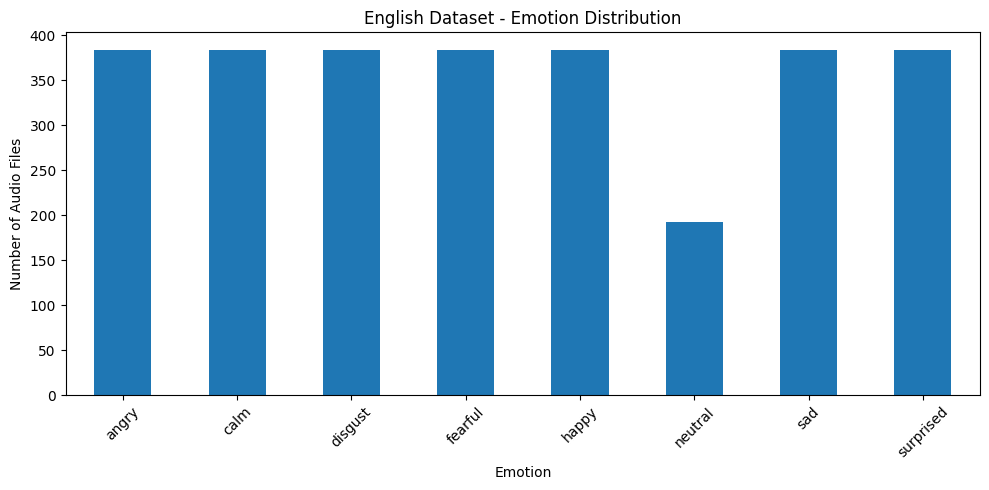

In [ ]:
plt.figure(figsize=(10, 5))

metadata["emotion"].value_counts().sort_index().plot(kind="bar")

plt.title("English Dataset - Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    RESULT_DIR / "english_emotion_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
sample_path = metadata.iloc[0]["file_path"]

y, sr = librosa.load(sample_path, sr=None, mono=True)

print("File:", sample_path)
print("Sampling rate:", sr, "Hz")
print("Duration:", round(len(y) / sr, 2), "seconds")
print("Number of samples:", len(y))

File: /content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-01-01-01.wav
Sampling rate: 48000 Hz
Duration: 3.67 seconds
Number of samples: 176176


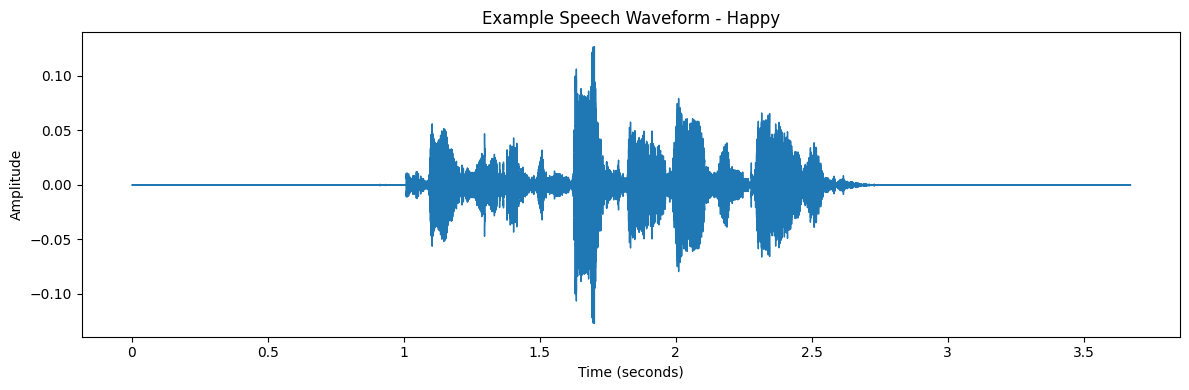

In [ ]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title(
    f"Example Speech Waveform - "
    f"{metadata.iloc[0]['emotion'].capitalize()}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [ ]:
TARGET_SR = 16000


def preprocess_audio(file_path, target_sr=TARGET_SR):
    y, sr = librosa.load(
        file_path,
        sr=target_sr,
        mono=True
    )

    # Remove leading/trailing silence
    y, _ = librosa.effects.trim(
        y,
        top_db=30
    )

    # Normalize amplitude
    max_value = np.max(np.abs(y))

    if max_value > 0:
        y = y / max_value

    return y, target_sr

In [ ]:
y_processed, sr_processed = preprocess_audio(sample_path)

print("Processed sampling rate:", sr_processed)
print("Processed duration:",
      round(len(y_processed) / sr_processed, 2),
      "seconds")

print(
    "Maximum amplitude:",
    round(np.max(np.abs(y_processed)), 4)
)

Processed sampling rate: 16000
Processed duration: 1.7 seconds
Maximum amplitude: 1.0


In [ ]:
def summarize_feature(feature):
    """
    Convert a variable-length feature matrix/vector
    into fixed-length statistics.
    """

    return np.hstack([
        np.mean(feature, axis=1),
        np.std(feature, axis=1)
    ])


def extract_features(file_path):

    y, sr = preprocess_audio(file_path)

    # Avoid errors with extremely short files
    if len(y) < 2048:
        raise ValueError("Audio file is too short.")

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=1024,
        hop_length=512
    )

    delta_mfcc = librosa.feature.delta(mfcc)

    delta2_mfcc = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Chroma
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )

    # RMS
    rms = librosa.feature.rms(
        y=y,
        frame_length=1024,
        hop_length=512
    )

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=1024,
        hop_length=512
    )

    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512
    )

    features = np.hstack([
        summarize_feature(mfcc),
        summarize_feature(delta_mfcc),
        summarize_feature(delta2_mfcc),
        summarize_feature(chroma),
        summarize_feature(rms),
        summarize_feature(zcr),
        summarize_feature(spectral_centroid),
        summarize_feature(spectral_bandwidth),
        summarize_feature(spectral_rolloff)
    ])

    return features

In [ ]:
sample_features = extract_features(sample_path)

print("Feature vector length:", len(sample_features))
print("First 20 values:")
print(sample_features[:20])

Feature vector length: 112
First 20 values:
[-2.60716248e+02  8.39821625e+01 -1.55470324e+01  8.31875229e+00
 -8.00703907e+00 -1.64288254e+01 -2.94564571e+01 -1.65716515e+01
 -2.72009106e+01  1.48733988e-01 -2.05517731e+01 -4.52080339e-01
 -1.78006973e+01  7.63556671e+01  5.02761879e+01  3.19538002e+01
  3.04115639e+01  3.29345131e+01  1.98923149e+01  1.79544964e+01]


In [ ]:
feature_rows = []
failed_files = []

print("Starting feature extraction...")
print("Total files:", len(metadata))

for i, row in metadata.iterrows():

    try:

        features = extract_features(row["file_path"])

        feature_rows.append({
            "file_path": row["file_path"],
            "speaker": row["speaker"],
            "emotion": row["emotion"],
            **{
                f"feature_{j}": value
                for j, value in enumerate(features)
            }
        })

    except Exception as e:

        failed_files.append({
            "file_path": row["file_path"],
            "error": str(e)
        })

    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(metadata)} files"
        )

features_df = pd.DataFrame(feature_rows)

print("\nFeature extraction completed.")
print("Successful files:", len(features_df))
print("Failed files:", len(failed_files))

Starting feature extraction...
Total files: 2880
Processed 100/2880 files
Processed 200/2880 files
Processed 300/2880 files
Processed 400/2880 files
Processed 500/2880 files
Processed 600/2880 files
Processed 700/2880 files
Processed 800/2880 files
Processed 900/2880 files
Processed 1000/2880 files
Processed 1100/2880 files
Processed 1200/2880 files
Processed 1300/2880 files
Processed 1400/2880 files
Processed 1500/2880 files
Processed 1600/2880 files
Processed 1700/2880 files
Processed 1800/2880 files
Processed 1900/2880 files
Processed 2000/2880 files
Processed 2100/2880 files
Processed 2200/2880 files
Processed 2300/2880 files
Processed 2400/2880 files
Processed 2500/2880 files
Processed 2600/2880 files
Processed 2700/2880 files
Processed 2800/2880 files

Feature extraction completed.
Successful files: 2878
Failed files: 2


In [ ]:
print("Feature dataset shape:")
print(features_df.shape)

display(features_df.head())

Feature dataset shape:
(2878, 115)


,file_path,speaker,emotion,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111
0,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,-260.716248,83.982162,-15.547032,8.318752,-8.007039,-16.428825,-29.456457,...,0.105329,0.070707,0.124005,0.089223,1714.431953,888.153591,1570.702880,350.970095,3022.858796,1542.882383
1,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,-301.496490,84.427444,-21.206820,13.944539,-2.915097,-15.089085,-19.840300,...,0.090227,0.078237,0.117367,0.098602,1602.688880,875.351654,1517.119572,351.857323,2938.020833,1425.989830
2,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,-214.280899,71.180229,-14.374216,12.520070,-8.426798,-15.449420,-19.068493,...,0.161314,0.100385,0.161520,0.170603,1988.130812,1231.795331,1590.527305,338.491399,3487.847222,1586.947738
3,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,happy,-238.045227,75.721252,-17.183123,10.375013,-9.133587,-13.950100,-21.095039,...,0.136225,0.085026,0.148010,0.162346,1873.631779,1213.495852,1521.020572,323.098749,3369.384766,1531.903478
4,/content/drive/MyDrive/SER_datasets/English_RA...,Actor_01,sad,-277.322876,103.996040,-6.385935,33.251312,-0.919006,-3.811994,-12.668797,...,0.092145,0.071131,0.114738,0.103989,1530.009242,866.414282,1483.311356,390.453387,2903.336864,1428.419513


In [ ]:
feature_columns = [
    col for col in features_df.columns
    if col.startswith("feature_")
]

X_all = features_df[feature_columns].values

print("NaN values:", np.isnan(X_all).sum())
print("Infinite values:", np.isinf(X_all).sum())
print("Feature count:", X_all.shape[1])

NaN values: 0
Infinite values: 0
Feature count: 112


In [ ]:
feature_csv = FEATURE_DIR / "English_features.csv"

features_df.to_csv(
    feature_csv,
    index=False
)

print("Feature dataset saved to:")
print(feature_csv)

Feature dataset saved to:
/content/features/English_features.csv


In [ ]:
X = features_df[feature_columns].values
y = features_df["emotion"].values
groups = features_df["speaker"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of speakers:", len(np.unique(groups)))

X shape: (2878, 112)
y shape: (2878,)
Number of speakers: 24


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Emotion encoding:")

for number, emotion in enumerate(label_encoder.classes_):
    print(number, "→", emotion)

Emotion encoding:
0 → angry
1 → calm
2 → disgust
3 → fearful
4 → happy
5 → neutral
6 → sad
7 → surprised


In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y_encoded,
        groups=groups
    )
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Training recordings:", len(X_train))
print("Testing recordings:", len(X_test))

print("\nTraining speakers:")
print(sorted(np.unique(groups_train)))

print("\nTesting speakers:")
print(sorted(np.unique(groups_test)))

print(
    "\nCommon speakers:",
    set(groups_train) & set(groups_test)
)

Training recordings: 2279
Testing recordings: 599

Training speakers:
['Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_10', 'Actor_11', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_18', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']

Testing speakers:
['Actor_01', 'Actor_09', 'Actor_12', 'Actor_17', 'Actor_19']

Common speakers: set()


In [ ]:
print("Training class distribution:")

train_emotions = label_encoder.inverse_transform(y_train)

print(
    pd.Series(train_emotions).value_counts().sort_index()
)

print("\nTest class distribution:")

test_emotions = label_encoder.inverse_transform(y_test)

print(
    pd.Series(test_emotions).value_counts().sort_index()
)

Training class distribution:
angry        304
calm         303
disgust      304
fearful      304
happy        304
neutral      152
sad          304
surprised    304
Name: count, dtype: int64

Test class distribution:
angry        80
calm         80
disgust      80
fearful      80
happy        80
neutral      40
sad          79
surprised    80
Name: count, dtype: int64


In [ ]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_sub_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

X_train_final = X_train[train_sub_idx]
X_val = X_train[val_idx]

y_train_final = y_train[train_sub_idx]
y_val = y_train[val_idx]

groups_train_final = groups_train[train_sub_idx]
groups_val = groups_train[val_idx]

print("Training:", len(X_train_final))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print(
    "\nTraining/Validation common speakers:",
    set(groups_train_final) & set(groups_val)
)

print(
    "Training/Test common speakers:",
    set(groups_train_final) & set(groups_test)
)

print(
    "Validation/Test common speakers:",
    set(groups_val) & set(groups_test)
)

Training: 1799
Validation: 480
Test: 599

Training/Validation common speakers: set()
Training/Test common speakers: set()
Validation/Test common speakers: set()


In [ ]:
models = {

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])
}

In [ ]:
baseline_results = []
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train_final,
        y_train_final
    )

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })

    trained_models[name] = model

baseline_results_df = pd.DataFrame(
    baseline_results
).sort_values(
    "Macro F1",
    ascending=False
)

display(baseline_results_df)


Training KNN...

Training Decision Tree...

Training Random Forest...

Training SVM...


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
3,SVM,0.591667,0.648316,0.574219,0.576846
2,Random Forest,0.520833,0.583659,0.519531,0.511381
0,KNN,0.391667,0.418119,0.390625,0.382298
1,Decision Tree,0.229167,0.218834,0.218750,0.216879


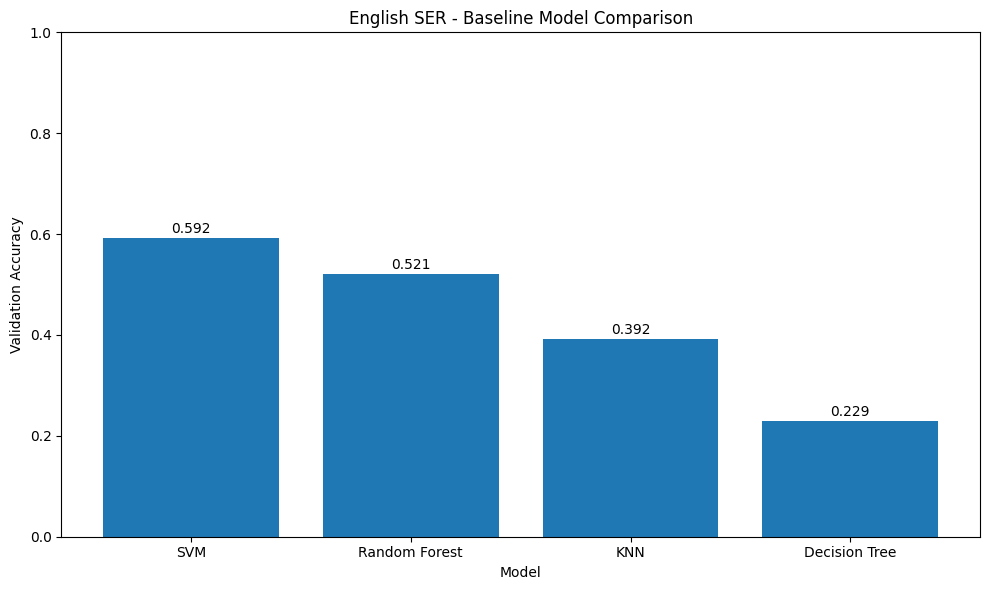

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    baseline_results_df["Model"],
    baseline_results_df["Accuracy"]
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model")
plt.title("English SER - Baseline Model Comparison")

plt.ylim(0, 1)

for i, value in enumerate(
    baseline_results_df["Accuracy"]
):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    RESULT_DIR / "english_baseline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
top_models = (
    baseline_results_df
    .sort_values("Macro F1", ascending=False)
    .head(2)["Model"]
    .tolist()
)

print("Models selected for tuning:")
for model in top_models:
    print("-", model)

Models selected for tuning:
- SVM
- Random Forest


In [ ]:
param_grids = {

    "SVM": {
        "classifier__C": [1, 10, 50],
        "classifier__gamma": ["scale", 0.01, 0.001],
        "classifier__kernel": ["rbf"]
    },

    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5]
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9],
        "classifier__weights": ["uniform", "distance"]
    },

    "Decision Tree": {
        "classifier__max_depth": [None, 5, 10, 20],
        "classifier__min_samples_split": [2, 5, 10]
    }
}

In [ ]:
tuned_models = {}
tuning_results = []

unique_train_speakers = np.unique(groups_train_final)

n_splits = min(
    5,
    len(unique_train_speakers)
)

group_cv = GroupKFold(
    n_splits=n_splits
)

for name in top_models:

    print(f"\nTuning {name}...")

    grid_search = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=group_cv,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(
        X_train_final,
        y_train_final,
        groups=groups_train_final
    )

    tuned_models[name] = grid_search.best_estimator_

    val_pred = grid_search.best_estimator_.predict(
        X_val
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    tuning_results.append({
        "Model": name,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": val_f1,
        "Best Parameters": grid_search.best_params_
    })

    print("Best parameters:")
    print(grid_search.best_params_)

tuning_results_df = pd.DataFrame(tuning_results)

display(tuning_results_df)


Tuning SVM...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters:
{'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

Tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}


,Model,Validation Accuracy,Validation Macro F1,Best Parameters
0,SVM,0.604167,0.588057,"{'classifier__C': 1, 'classifier__gamma': 0.01..."
1,Random Forest,0.529167,0.529045,"{'classifier__max_depth': None, 'classifier__m..."


In [ ]:
all_candidates = []

for name, model in trained_models.items():

    pred = model.predict(X_val)

    all_candidates.append({
        "Model": name,
        "Type": "Baseline",
        "Accuracy": accuracy_score(y_val, pred),
        "Macro F1": f1_score(
            y_val,
            pred,
            average="macro",
            zero_division=0
        ),
        "Model Object": model
    })

for name, model in tuned_models.items():

    pred = model.predict(X_val)

    all_candidates.append({
        "Model": name,
        "Type": "Tuned",
        "Accuracy": accuracy_score(y_val, pred),
        "Macro F1": f1_score(
            y_val,
            pred,
            average="macro",
            zero_division=0
        ),
        "Model Object": model
    })

candidate_df = pd.DataFrame(all_candidates)

candidate_df = candidate_df.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    candidate_df[
        ["Model", "Type", "Accuracy", "Macro F1"]
    ]
)

best_model_name = candidate_df.iloc[0]["Model"]
best_model_type = candidate_df.iloc[0]["Type"]
best_model = candidate_df.iloc[0]["Model Object"]

print("\nSelected model:", best_model_name)
print("Model type:", best_model_type)

,Model,Type,Accuracy,Macro F1
0,SVM,Tuned,0.604167,0.588057
1,SVM,Baseline,0.591667,0.576846
2,Random Forest,Tuned,0.529167,0.529045
3,Random Forest,Baseline,0.520833,0.511381
4,KNN,Baseline,0.391667,0.382298
5,Decision Tree,Baseline,0.229167,0.216879



Selected model: SVM
Model type: Tuned


In [ ]:
X_train_complete = np.concatenate(
    [X_train_final, X_val],
    axis=0
)

y_train_complete = np.concatenate(
    [y_train_final, y_val],
    axis=0
)

groups_train_complete = np.concatenate(
    [groups_train_final, groups_val],
    axis=0
)

print("Final training recordings:",
      len(X_train_complete))

print("Final test recordings:",
      len(X_test))

print(
    "Train/Test speaker overlap:",
    set(groups_train_complete) & set(groups_test)
)

Final training recordings: 2279
Final test recordings: 599
Train/Test speaker overlap: set()


In [ ]:
final_model = best_model

final_model.fit(
    X_train_complete,
    y_train_complete
)

print("Final model trained successfully.")

Final model trained successfully.


In [ ]:
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("========================================")
print("FINAL ENGLISH SER RESULTS")
print("========================================")
print(f"Model:           {best_model_name}")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1:        {test_f1:.4f}")
print("========================================")

FINAL ENGLISH SER RESULTS
Model:           SVM
Accuracy:        0.5092
Macro Precision: 0.5795
Macro Recall:    0.4932
Macro F1:        0.4989


In [ ]:
target_names = label_encoder.classes_

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry     0.8929    0.6250    0.7353        80
        calm     0.6250    0.7500    0.6818        80
     disgust     0.5938    0.4750    0.5278        80
     fearful     0.4773    0.5250    0.5000        80
       happy     0.6333    0.4750    0.5429        80
     neutral     0.5556    0.2500    0.3448        40
         sad     0.2746    0.6709    0.3897        79
   surprised     0.5833    0.1750    0.2692        80

    accuracy                         0.5092       599
   macro avg     0.5795    0.4932    0.4989       599
weighted avg     0.5816    0.5092    0.5094       599



<Figure size 900x800 with 0 Axes>

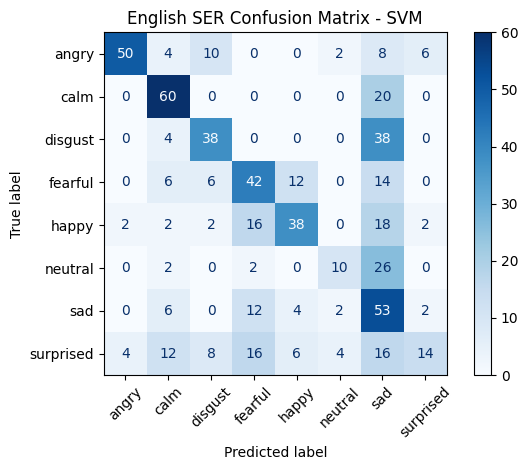

In [ ]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title(
    f"English SER Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR / "english_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
english_model_path = MODEL_DIR / "english_ser_model.pkl"
english_encoder_path = MODEL_DIR / "english_label_encoder.pkl"

joblib.dump(
    final_model,
    english_model_path
)

joblib.dump(
    label_encoder,
    english_encoder_path
)

print("Model saved:")
print(english_model_path)

print("\nLabel encoder saved:")
print(english_encoder_path)

Model saved:
/content/models/english_ser_model.pkl

Label encoder saved:
/content/models/english_label_encoder.pkl


In [ ]:
final_results = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Value": [
        best_model_name,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

final_results.to_csv(
    RESULT_DIR / "english_final_results.csv",
    index=False
)

display(final_results)

,Metric,Value
0,Model,SVM
1,Accuracy,0.509182
2,Macro Precision,0.579464
3,Macro Recall,0.493236
4,Macro F1,0.498939


In [ ]:
def predict_emotion(audio_path):

    features = extract_features(audio_path)

    features = features.reshape(1, -1)

    prediction_encoded = final_model.predict(
        features
    )[0]

    emotion = label_encoder.inverse_transform(
        [prediction_encoded]
    )[0]

    result = {
        "emotion": emotion
    }

    # SVC provides probabilities because
    # probability=True was used.
    if hasattr(final_model, "predict_proba"):

        probabilities = final_model.predict_proba(
            features
        )[0]

        classes = label_encoder.inverse_transform(
            np.arange(len(probabilities))
        )

        probability_dict = {
            emotion_name: float(probability)
            for emotion_name, probability
            in zip(classes, probabilities)
        }

        result["probabilities"] = probability_dict

    return result

In [ ]:
test_example_index = test_idx[0]

test_example_path = metadata.iloc[
    test_example_index
]["file_path"]

actual_emotion = metadata.iloc[
    test_example_index
]["emotion"]

prediction_result = predict_emotion(
    test_example_path
)

print("========================================")
print("ENGLISH SPEECH EMOTION RECOGNITION")
print("========================================")

print("Audio:")
print(test_example_path)

print("\nActual emotion:")
print(actual_emotion)

print("\nPredicted emotion:")
print(prediction_result["emotion"])

if "probabilities" in prediction_result:

    print("\nClass probabilities:")

    for emotion, probability in sorted(
        prediction_result["probabilities"].items(),
        key=lambda x: x[1],
        reverse=True
    ):
        print(
            f"{emotion:10s}: {probability * 100:.2f}%"
        )

print("========================================")

ENGLISH SPEECH EMOTION RECOGNITION
Audio:
/content/drive/MyDrive/SER_datasets/English_RAVDESS/Actor_01/03-01-03-02-01-01-01.wav

Actual emotion:
happy

Predicted emotion:
happy

Class probabilities:
happy     : 93.34%
surprised : 2.57%
angry     : 1.81%
fearful   : 1.72%
neutral   : 0.34%
sad       : 0.17%
disgust   : 0.02%
calm      : 0.02%


In [ ]:
from google.colab import files

print("Upload an English speech audio file.")

uploaded = files.upload()

Upload an English speech audio file.


Saving 03-01-03-02-02-02-07.wav to 03-01-03-02-02-02-07.wav


In [ ]:
uploaded_filename = list(uploaded.keys())[0]

print("Uploaded file:")
print(uploaded_filename)

Uploaded file:
03-01-03-02-02-02-07.wav


In [ ]:
result = predict_emotion(
    uploaded_filename
)

print("\n========================================")
print("       SPEECH EMOTION RECOGNITION")
print("========================================")

print("Language: English")
print("Audio:", uploaded_filename)

print("\nPredicted Emotion:")
print(result["emotion"].upper())

if "probabilities" in result:

    print("\nClass probabilities:")

    for emotion, probability in sorted(
        result["probabilities"].items(),
        key=lambda x: x[1],
        reverse=True
    ):

        print(
            f"{emotion.capitalize():10s} "
            f"{probability * 100:.2f}%"
        )

print("========================================")


       SPEECH EMOTION RECOGNITION
Language: English
Audio: 03-01-03-02-02-02-07.wav

Predicted Emotion:
HAPPY

Class probabilities:
Happy      99.18%
Fearful    0.29%
Angry      0.21%
Surprised  0.14%
Disgust    0.09%
Neutral    0.04%
Sad        0.04%
Calm       0.01%


In [ ]:
from IPython.display import Audio, display

display(
    Audio(
        uploaded_filename
    )
)

In [ ]:
print("==============================================")
print("       ENGLISH SPEECH EMOTION RECOGNITION")
print("==============================================")

print(f"Total recordings:     {len(metadata)}")
print(f"Total speakers:       {metadata['speaker'].nunique()}")
print(f"Emotion classes:      {metadata['emotion'].nunique()}")

print("\nEmotion classes:")
print(", ".join(label_encoder.classes_))

print("\nFinal model:")
print(best_model_name)

print("\nFinal test performance:")
print(f"Accuracy:        {test_accuracy * 100:.2f}%")
print(f"Macro Precision: {test_precision * 100:.2f}%")
print(f"Macro Recall:    {test_recall * 100:.2f}%")
print(f"Macro F1:        {test_f1 * 100:.2f}%")

print("\nSpeaker-independent testing: YES")
print("Web application: NO")
print("Feature extraction: MFCC + acoustic features")
print("==============================================")

       ENGLISH SPEECH EMOTION RECOGNITION
Total recordings:     2880
Total speakers:       24
Emotion classes:      8

Emotion classes:
angry, calm, disgust, fearful, happy, neutral, sad, surprised

Final model:
SVM

Final test performance:
Accuracy:        50.92%
Macro Precision: 57.95%
Macro Recall:    49.32%
Macro F1:        49.89%

Speaker-independent testing: YES
Web application: NO
Feature extraction: MFCC + acoustic features
